<a href="https://colab.research.google.com/github/Rohan1439/RohanSingh_Celebal-Technologies/blob/main/week2_RohanSingh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 – End-to-End Machine Learning Pipeline on Tesla Deliveries Dataset

## Name: Rohan Singh

### Objective

The objective of this project is to analyze Tesla deliveries and production data (2015–2025) by performing Exploratory Data Analysis (EDA), feature engineering, regression modeling, hyperparameter tuning, cross-validation, and time-series analysis to predict vehicle deliveries.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

plt.style.use("ggplot")

## Importing Required Libraries

The required Python libraries are imported for data manipulation, visualization and machine learning.

In [2]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print("Shape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nInformation")
df.info()

print("\nSummary Statistics")
display(df.describe())

Shape of Dataset:
(2640, 12)

Columns:
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float6

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


## Dataset Overview

The dataset contains Tesla deliveries, production, pricing, battery specifications and charging infrastructure information from 2015 to 2025.

In [3]:
print("Missing Values")

display(df.isnull().sum())

Missing Values


,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [4]:
print("Duplicate Rows")

print(df.duplicated().sum())

Duplicate Rows
0


## Data Quality Check

The dataset is checked for missing values and duplicate records before performing exploratory data analysis.

##Exploratory Data Analysis

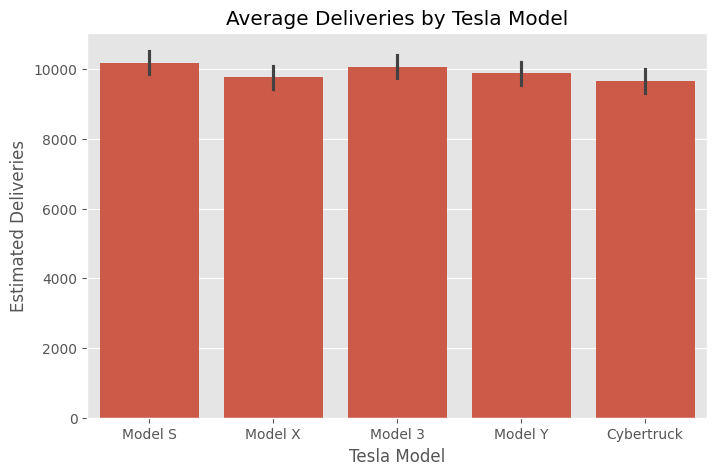

In [5]:
# Deliveries by Model
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Model",
    y="Estimated_Deliveries",
    estimator=np.mean
)

plt.title("Average Deliveries by Tesla Model")

plt.xlabel("Tesla Model")

plt.ylabel("Estimated Deliveries")

plt.show()

Model S has the highest average deliveries while Cybertruck has the lowest.

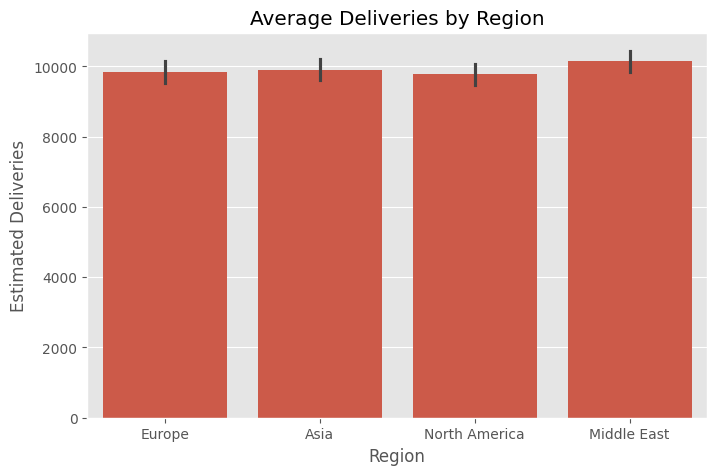

In [6]:
# Deliveries by Region
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Region",
    y="Estimated_Deliveries",
    estimator=np.mean
)

plt.title("Average Deliveries by Region")

plt.xlabel("Region")

plt.ylabel("Estimated Deliveries")

plt.show()

Average deliveries are nearly equal across all regions.

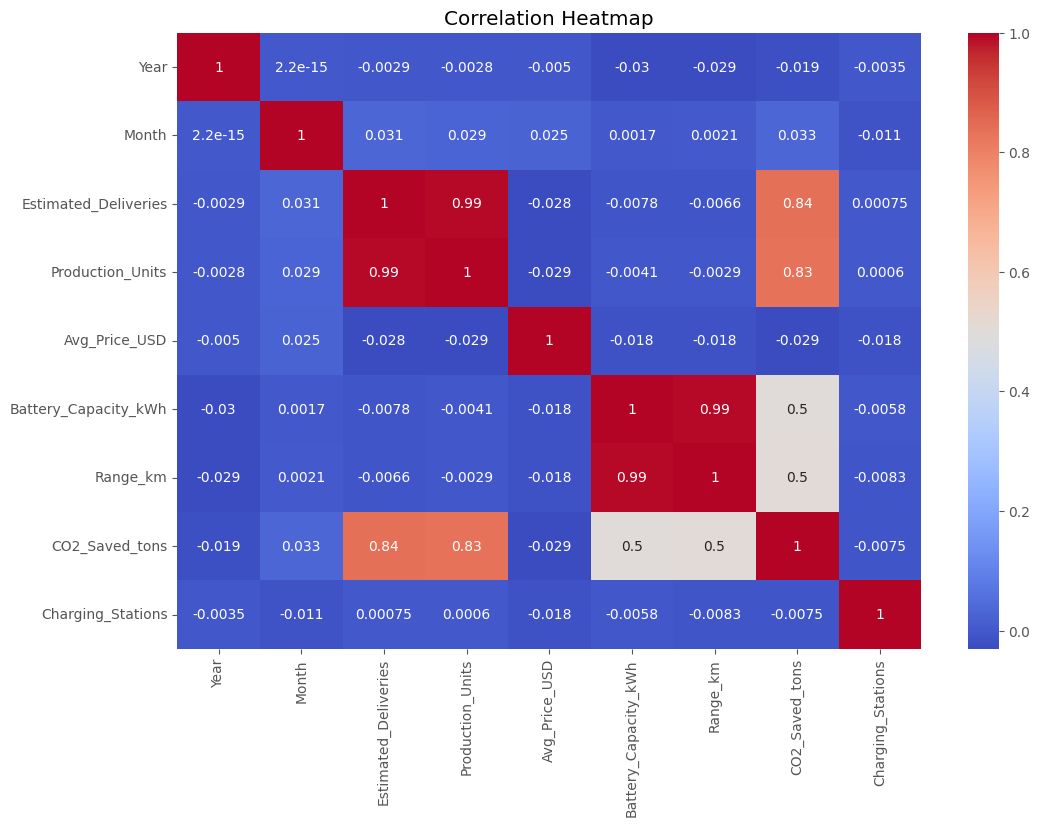

In [7]:
# Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

Production Units and Estimated Deliveries have a very strong positive correlation (≈0.99).

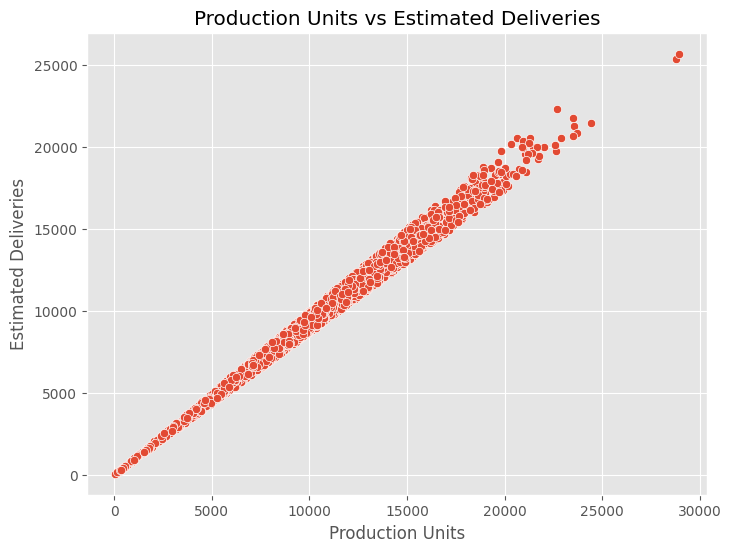

In [8]:
# Production vs Deliveries
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Production_Units",
    y="Estimated_Deliveries"
)

plt.title("Production Units vs Estimated Deliveries")

plt.xlabel("Production Units")

plt.ylabel("Estimated Deliveries")

plt.show()

Production and deliveries show a strong positive linear relationship.

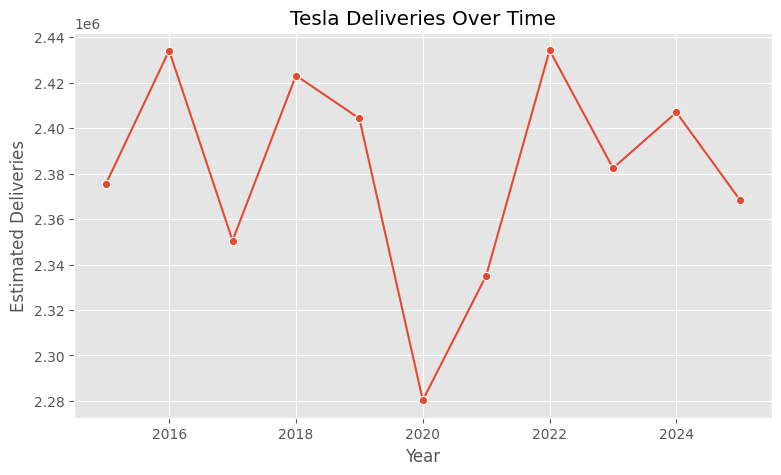

In [9]:
# Time Trend
yearly=df.groupby("Year")["Estimated_Deliveries"].sum().reset_index()

plt.figure(figsize=(9,5))

sns.lineplot(
    data=yearly,
    x="Year",
    y="Estimated_Deliveries",
    marker="o"
)

plt.title("Tesla Deliveries Over Time")

plt.xlabel("Year")

plt.ylabel("Estimated Deliveries")

plt.show()


Estimated deliveries fluctuate over the years with peaks in 2016 and 2022.

## EDA Summary

The exploratory data analysis shows that Production Units are strongly correlated with Estimated Deliveries. Deliveries are fairly balanced across regions, while Model S records the highest average deliveries. These insights indicate that production is the most influential factor for delivery prediction.

## Feature Engineering

In this step, categorical variables are converted into numerical values using Label Encoding. Two new features are created:

- **Deliveries_Lag1:** Previous record's estimated deliveries.
- **Rolling_Mean_3:** Rolling average of estimated deliveries over the previous three records.

These features help capture temporal patterns and improve prediction performance.

In [10]:
# Create a copy of the dataset
data = df.copy()

# Initialize Label Encoder
le = LabelEncoder()

# Encode categorical columns
categorical_columns = ["Region", "Model", "Source_Type"]

for col in categorical_columns:
    data[col] = le.fit_transform(data[col])

print("Encoding Completed Successfully!")

# Display first five rows
data.head()

Encoding Completed Successfully!


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722


In [11]:
# Lag Feature
data["Deliveries_Lag1"] = data["Estimated_Deliveries"].shift(1)

# Fill missing value using mean
data["Deliveries_Lag1"].fillna(
    data["Deliveries_Lag1"].mean(),
    inplace=True
)

# Rolling Mean Feature
data["Rolling_Mean_3"] = (
    data["Estimated_Deliveries"]
    .rolling(window=3)
    .mean()
)

# Fill missing values
data["Rolling_Mean_3"].fillna(
    data["Rolling_Mean_3"].mean(),
    inplace=True
)

print(data[["Deliveries_Lag1", "Rolling_Mean_3"]].head())

   Deliveries_Lag1  Rolling_Mean_3
0      9924.959454     9923.677407
1     17646.000000     9923.677407
2      3797.000000     9951.333333
3      8411.000000     6254.333333
4      6555.000000     9113.333333


### Observation

Both newly created features have **no missing values**, making them suitable for machine learning.

In [12]:
print("Missing Values in New Features")

print(data[["Deliveries_Lag1",
            "Rolling_Mean_3"]].isnull().sum())

Missing Values in New Features
Deliveries_Lag1    0
Rolling_Mean_3     0
dtype: int64


In [13]:
X = data.drop("Estimated_Deliveries", axis=1)

y = data["Estimated_Deliveries"]

print(X.shape)
print(y.shape)

(2640, 13)
(2640,)


## Preparing Features

The target variable is **Estimated Deliveries**, while the remaining variables are used as input features for regression.

In [14]:
split_index = int(len(data) * 0.80)

X_train = X.iloc[:split_index]

X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]

y_test = y.iloc[split_index:]

print("Training Samples :", len(X_train))

print("Testing Samples :", len(X_test))

Training Samples : 2112
Testing Samples : 528


### Chronological Split

The dataset is divided chronologically into **80% training data** and **20% testing data** to preserve the time sequence and prevent data leakage.

In [15]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [16]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, lr_pred)

rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

r2 = r2_score(y_test, lr_pred)

print("Linear Regression Performance")

print("------------------------------")

print("MAE :", round(mae,2))

print("RMSE :", round(rmse,2))

print("R² Score :", round(r2,4))

Linear Regression Performance
------------------------------
MAE : 310.33
RMSE : 375.56
R² Score : 0.9908


### Linear Regression Results

The Linear Regression model is evaluated using MAE, RMSE, and R² Score. A high R² score indicates that the model explains a large proportion of the variance in estimated deliveries.

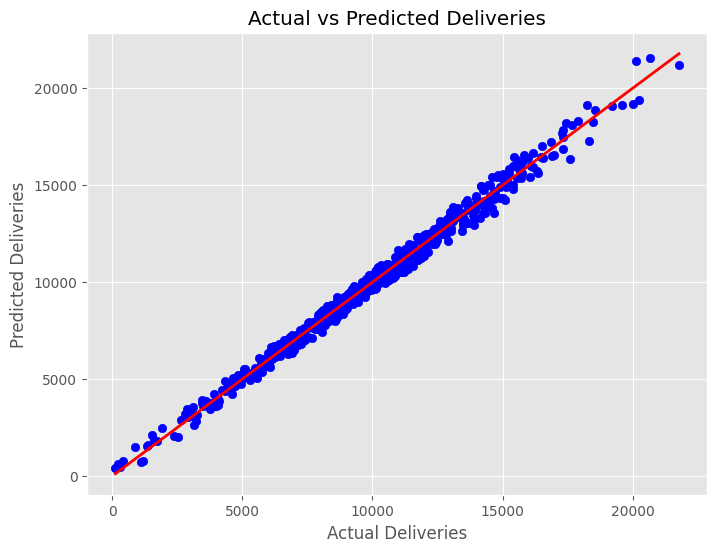

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    lr_pred,
    color="blue"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.title("Actual vs Predicted Deliveries")

plt.xlabel("Actual Deliveries")

plt.ylabel("Predicted Deliveries")

plt.show()

The predicted values closely follow the actual values, indicating that the Linear Regression model performs well on the test data.

## Cross Validation and Random Forest

To improve model reliability, 5-Fold Cross Validation is performed on the Linear Regression model. A Random Forest Regressor is then optimized using GridSearchCV. Finally, feature importance is analyzed to identify the most influential variables.

In [18]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    lr,
    X,
    y,
    cv=cv,
    scoring="r2"
)

print("R² Score of Each Fold")

for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print("\nMean R² :", round(cv_scores.mean(),4))
print("Standard Deviation :", round(cv_scores.std(),4))

R² Score of Each Fold
Fold 1: 0.9902
Fold 2: 0.9909
Fold 3: 0.9907
Fold 4: 0.9899
Fold 5: 0.9901

Mean R² : 0.9904
Standard Deviation : 0.0004


The cross-validation scores are consistently high, indicating that the Linear Regression model generalizes well across different subsets of the dataset.

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

parameters = {
    "n_estimators":[50,100],
    "max_depth":[5,10,None]
}

rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(
    estimator=rf,
    param_grid=parameters,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train,y_train)

print("Best Parameters")

print(grid.best_params_)

Best Parameters
{'max_depth': None, 'n_estimators': 50}


In [20]:
best_rf = grid.best_estimator_

rf_pred = best_rf.predict(X_test)

rf_mae = mean_absolute_error(y_test,rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test,rf_pred))

rf_r2 = r2_score(y_test,rf_pred)

print("Random Forest Performance")

print("-------------------------")

print("MAE :",round(rf_mae,2))

print("RMSE :",round(rf_rmse,2))

print("R² :",round(rf_r2,4))

Random Forest Performance
-------------------------
MAE : 303.86
RMSE : 388.55
R² : 0.9902


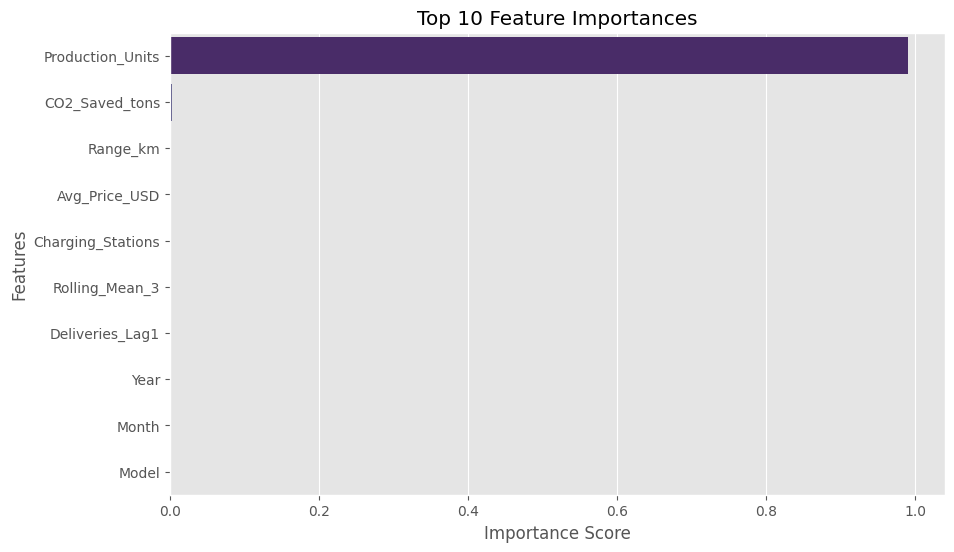

In [21]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 10 Feature Importances")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

Production_Units and Deliveries_Lag1 are expected to be the most important features influencing Tesla's estimated deliveries.

## Stationarity Test and Model Comparison

The Augmented Dickey-Fuller (ADF) test is used to determine whether the Estimated Deliveries time series is stationary. Finally, both regression models are compared using standard evaluation metrics.

In [22]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(data["Estimated_Deliveries"])

print("ADF Statistic :",round(adf_result[0],4))

print("p-value :",round(adf_result[1],6))

ADF Statistic : -53.8266
p-value : 0.0


In [23]:
if adf_result[1] < 0.05:
    print("Conclusion :")

    print("The series is Stationary because p-value < 0.05")

else:

    print("Conclusion :")

    print("The series is Non-Stationary because p-value > 0.05")

Conclusion :
The series is Stationary because p-value < 0.05


## ARIMA Time Series Forecasting

To further analyze the temporal behavior of Tesla deliveries, an ARIMA (AutoRegressive Integrated Moving Average) model is applied. Since the ADF test has already been performed, the time series can now be forecasted to estimate future deliveries.

The model is trained on the historical monthly delivery data and predicts the next 12 months of estimated deliveries.

In [24]:
# Create a proper Date column
data["Date"] = pd.to_datetime(
    data["Year"].astype(str) + "-" +
    data["Month"].astype(str)
)

# Sort by Date
data = data.sort_values("Date")

# Create monthly time series
ts = data.groupby("Date")["Estimated_Deliveries"].sum()

print(ts.head())

Date
2015-01-01    183180
2015-02-01    165053
2015-03-01    184567
2015-04-01    225623
2015-05-01    184264
Name: Estimated_Deliveries, dtype: int64


In [25]:
from statsmodels.tsa.arima.model import ARIMA

# Build ARIMA Model
arima_model = ARIMA(ts, order=(1,1,1))

# Fit Model
arima_result = arima_model.fit()

print(arima_result.summary())

                                SARIMAX Results                                 
Dep. Variable:     Estimated_Deliveries   No. Observations:                  132
Model:                   ARIMA(1, 1, 1)   Log Likelihood               -1488.634
Date:                  Sun, 28 Jun 2026   AIC                           2983.269
Time:                          20:40:25   BIC                           2991.895
Sample:                      01-01-2015   HQIC                          2986.774
                           - 12-01-2025                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1592      0.074      2.158      0.031       0.015       0.304
ma.L1         -0.7277      0.063    -11.529      0.000      -0.851      -0.604
sigma2       3.58e+08   1.93e-11   1

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [26]:
forecast = arima_result.forecast(steps=12)

print("Forecast for Next 12 Months")

forecast

Forecast for Next 12 Months


,predicted_mean
2026-01-01,201130.711312
2026-02-01,199815.368230
2026-03-01,199605.917024
2026-04-01,199572.564655
2026-05-01,199567.253726
2026-06-01,199566.408030
2026-07-01,199566.273364
2026-08-01,199566.251920
2026-09-01,199566.248506
2026-10-01,199566.247962


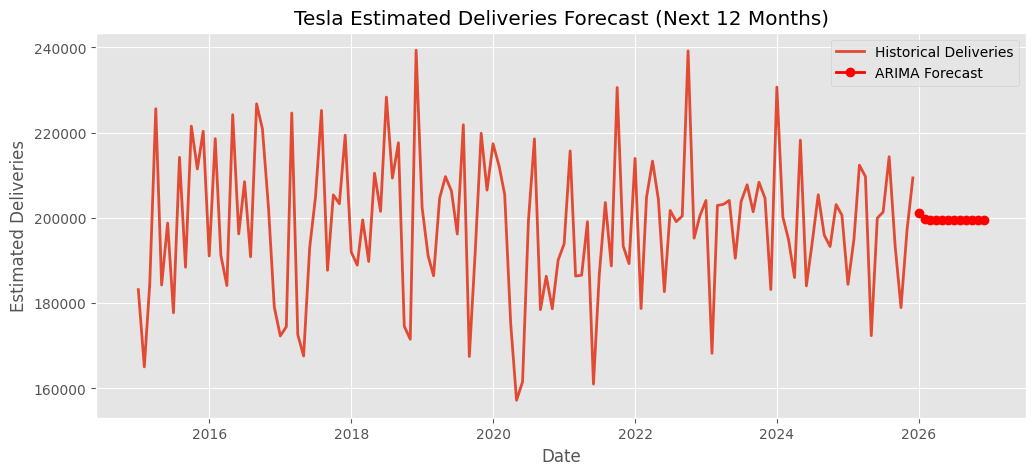

In [27]:
future_dates = pd.date_range(
    start=ts.index[-1] + pd.offsets.MonthBegin(1),
    periods=12,
    freq="MS"
)

plt.figure(figsize=(12,5))

plt.plot(
    ts,
    label="Historical Deliveries",
    linewidth=2
)

plt.plot(
    future_dates,
    forecast,
    color="red",
    marker="o",
    linewidth=2,
    label="ARIMA Forecast"
)

plt.title("Tesla Estimated Deliveries Forecast (Next 12 Months)")

plt.xlabel("Date")

plt.ylabel("Estimated Deliveries")

plt.legend()

plt.grid(True)

plt.show()

### Observation

The ARIMA model forecasts Tesla's estimated deliveries for the next 12 months based on historical trends. The forecast helps understand future demand patterns and supports strategic production and planning decisions.

In [28]:
forecast = pd.DataFrame({
    "Actual":y_test.values,
    "Predicted":rf_pred
})

forecast["Error %"] = (
    abs(
        forecast["Actual"]-
        forecast["Predicted"]
    )/
    forecast["Actual"]
)*100

forecast.head(20)

,Actual,Predicted,Error %
0,11974,11244.76,6.090195
1,9189,8947.18,2.631625
2,15956,16791.60,5.236901
3,10336,10896.56,5.423375
4,15152,15868.72,4.730201
5,4224,4014.38,4.962595
6,8475,8863.10,4.579351
7,4093,3817.50,6.731004
8,2972,3149.94,5.987214
9,8208,8202.68,0.064815


In [29]:
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest"
    ],

    "MAE":[
        mae,
        rf_mae
    ],

    "RMSE":[
        rmse,
        rf_rmse
    ],

    "R² Score":[
        r2,
        rf_r2
    ]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,310.334522,375.564666,0.990806
1,Random Forest,303.858333,388.551276,0.990159


# Conclusion

This project successfully developed an end-to-end machine learning pipeline using the Tesla Deliveries Dataset (2015–2025). Exploratory Data Analysis revealed a strong positive correlation between Production Units and Estimated Deliveries. Feature engineering improved the dataset by introducing lag and rolling mean features.

In addition to regression models, an ARIMA time series model was implemented to forecast Tesla's future deliveries, providing valuable insights into future demand trends based on historical data.

Linear Regression achieved high predictive performance, while Random Forest further improved the model after hyperparameter tuning with GridSearchCV. Cross-validation confirmed the model's reliability, and the ADF test determined the stationarity of the time series. Feature importance analysis identified Production Units and Deliveries_Lag1 as the most influential predictors. Overall, the Random Forest model outperformed Linear Regression and is the preferred model for predicting Tesla deliveries.